<a href="https://colab.research.google.com/github/gilIolgenblum/CrowdingModeWorkshop/blob/main/tutorials/solutions/E1_forward_simulation_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1 — Solution: Forward Simulation

> ⚠️ **This is the solution notebook.** Students should attempt the exercises independently first.

In [1]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    # Clone the repository to get the data files
    !git clone https://github.com/gilIolgenblum/CrowdingModeWorkshop.git
    # Change the working directory to the repository root
    os.chdir('/content/CrowdingModeWorkshop')
    # Install the package dependencies
    !pip install -e .

    # TELL PYTHON WHERE THE SOURCE FOLDER IS
    sys.path.append('/content/CrowdingModeWorkshop/src')

In [2]:
import crowding as cr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

---
## Task A1 — Build a Model from Scratch

**System:** AQ16 protein in Sucrose solution.

Parameters:
- **AQ16:** SASA = 242.6 Å²
- **Sucrose:** ν = 11.9, χ = 0.452, χ_TS = −0.854
- Set **eps = 0**, **epsTS = 0** (no soft interaction for now)
- Use `phiC_max=0.20` and `dphiC=0.001`

**Steps:**
1. Create a `cr.Protein` and a `cr.Cosolute`.
2. Build and solve a `cr.CrowdingModel`.
3. Print the predicted **ΔΔG⁰** (in kJ/mol) at **φ = 0.10**.

*Hint: `model.phiC` contains the volume fraction array and `model.ddA_kj` contains the ΔΔG⁰ array.*

In [4]:
# Define Protein (AQ16)
AQ16 = cr.Protein(SASA=242.6)

# Define Sucrose Cosolute
sucrose = cr.Cosolute(nu=11.9, chi=0.452, chiTS=-0.854)

# Build and solve the model
model_sucrose = cr.CrowdingModel(
    protein=AQ16,
    cosolute=sucrose,
    eps=0.0, epsTS=0.0,
    phiC_max=0.20, dphiC=0.001
)
model_sucrose.solve_equil()

# Extract ΔΔG⁰ at φ = 0.10
idx = np.argmin(np.abs(model_sucrose.phiC - 0.10))
ddG_at_010 = model_sucrose.ddA_kj[idx]
print(f"ΔΔG⁰ at φ=0.10: {ddG_at_010:.4f} kJ/mol")

ΔΔG⁰ at φ=0.10: -0.4498 kJ/mol


---
## Task A2 — Compare Two Cosolutes

**System:** AQ16 in Sucrose vs. AQ16 in Glycerol.

Glycerol parameters: ν = 2.479, χ = 0.610, χ_TS = −3.650

**Steps:**
1. Reuse your Sucrose model from Task A1.
2. Create a second `cr.CrowdingModel` for AQ16 + Glycerol (same `eps=0`).
3. Plot **ΔΔG⁰ vs φ** for **both** cosolutes on the **same axes** with a legend.

**Question (answer below):** Which cosolute stabilizes AQ16 more at φ = 0.10? explain the result!


*Hint: try plotting ΔΔG⁰ other concentrations.*

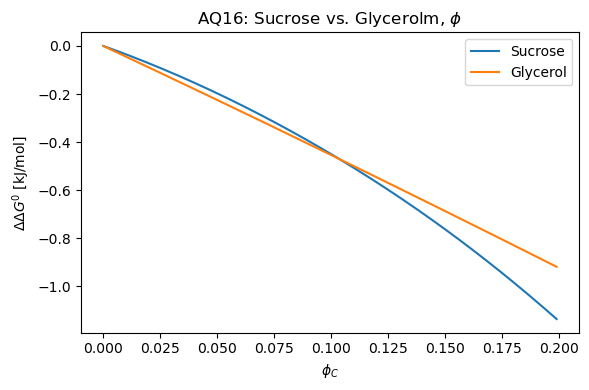

Sucrose  ΔΔG⁰ at φ=0.10: -0.4498 kJ/mol
Glycerol ΔΔG⁰ at φ=0.10: -0.4536 kJ/mol


In [22]:
# Glycerol cosolute
glycerol = cr.Cosolute(nu=2.479, chi=0.452610, chiTS=-3.650)
model_glycerol = cr.CrowdingModel(
    protein=AQ16, cosolute=glycerol,
    eps=0.0, epsTS=0.0,
    phiC_max=0.20, dphiC=0.001
)
model_glycerol.solve_equil()

# Plot comparison
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(model_sucrose.phiC, model_sucrose.ddA_kj, label="Sucrose")
ax.plot(model_glycerol.phiC, model_glycerol.ddA_kj, label="Glycerol")
ax.set_xlabel(r"$\phi_C$")
ax.set_ylabel(r"$\Delta\Delta G^0$ [kJ/mol]")
ax.legend()
ax.set_title(r"AQ16: Sucrose vs. Glycerolm, $\phi$")
plt.tight_layout()
plt.show()

# At phi=0.10
idx = np.argmin(np.abs(model_sucrose.phiC - 0.10))
print(f"Sucrose  ΔΔG⁰ at φ=0.10: {model_sucrose.ddA_kj[idx]:.4f} kJ/mol")
print(f"Glycerol ΔΔG⁰ at φ=0.10: {model_glycerol.ddA_kj[idx]:.4f} kJ/mol")

**Answer:** Glycerol and sucrose stabilize AQ16 to approximately the same extent at $\phi = 0.10$ because of a balance between the **number of excluded-volume interactions** and their **strength per cosolute molecule**.

Sucrose has a larger excluded volume than glycerol ($\nu_{\mathrm{suc}} > \nu_{\mathrm{gly}}$), resulting in a stronger excluded-volume effect per cosolute molecule. However, at the same volume fraction ($\phi = 0.10$), the solution contains fewer sucrose molecules than glycerol molecules because each sucrose molecule occupies a larger volume. At $\phi = 0.10$, these two effects approximately compensate, resulting in similar stabilization of AQ16.

This relationship becomes clearer when $\Delta\Delta G^0$ is plotted against **molality**, which reflects the number of cosolute molecules relative to the amount of solvent rather than the volume occupied by the cosolute.

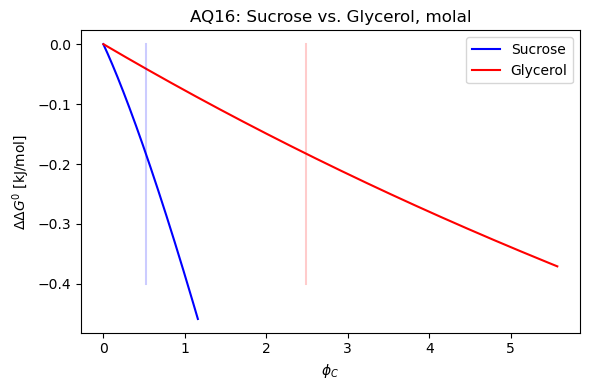

<IPython.core.display.Math object>

In [54]:
# Plot comparison
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(model_sucrose.molal, model_sucrose.ddA, 'b', label="Sucrose")
ax.plot(model_glycerol.molal, model_glycerol.ddA, 'r', label="Glycerol")
ax.set_xlabel(r"$\phi_C$")
ax.set_ylabel(r"$\Delta\Delta G^0$ [kJ/mol]")
idx_suc, idx_gly = np.argmin(np.abs(model_sucrose.phiC - 0.10)), np.argmin(np.abs(model_glycerol.phiC - 0.10))
phi0p1_suc, phi0p1_gly = model_sucrose.molal[idx_suc], model_glycerol.molal[idx_gly]
ax.plot([phi0p1_suc,phi0p1_suc],[0,-0.4],'b',alpha=0.2)
ax.plot([phi0p1_gly,phi0p1_gly],[0,-0.4],'r',alpha=0.2)
ax.legend()
ax.set_title("AQ16: Sucrose vs. Glycerol, molal")
plt.tight_layout()
plt.show()

from IPython.display import display, Math

display(Math(
    rf'''
    \begin{{aligned}}
    \mathrm{{molal}}_\mathrm{{suc}}(\phi=0.10) &\sim {phi0p1_suc:.2f} \\
    \mathrm{{molal}}_\mathrm{{gly}}(\phi=0.10) &\sim {phi0p1_gly:.2f}
    \end{{aligned}}
    '''
))

---
## Task A3 — Sensitivity to ν

In [ ]:
# Glycerol with doubled nu
glycerol_2nu = cr.Cosolute(nu=5.0, chi=0.610, chiTS=-3.650)
model_glycerol_2nu = cr.CrowdingModel(
    protein=AQ16, cosolute=glycerol_2nu,
    eps=0.0, epsTS=0.0,
    phiC_max=0.20, dphiC=0.001
)
model_glycerol_2nu.solve()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ΔΔG⁰
axes[0].plot(model_glycerol.phiC, model_glycerol.ddA_kj, label=r"$\nu=2.479$")
axes[0].plot(model_glycerol_2nu.phiC, model_glycerol_2nu.ddA_kj, label=r"$\nu=5.0$")
axes[0].set_xlabel(r"$\phi_C$")
axes[0].set_ylabel(r"$\Delta\Delta G^0$ [kJ/mol]")
axes[0].legend()
axes[0].set_title(r"$\Delta\Delta G^0$")

# TΔΔSi⁰
axes[1].plot(model_glycerol.phiC, model_glycerol.TddS_kj, label=r"$\nu=2.479$")
axes[1].plot(model_glycerol_2nu.phiC, model_glycerol_2nu.TddS_kj, label=r"$\nu=5.0$")
axes[1].set_xlabel(r"$\phi_C$")
axes[1].set_ylabel(r"$T\Delta\Delta S^0$ [kJ/mol]")
axes[1].legend()
axes[1].set_title(r"$T\Delta\Delta S^0$")

plt.tight_layout()
plt.show()

**Answer:** ΔΔH⁰ does **not** change when ν is doubled.  
In the Flory-Huggins model, ν controls the excluded volume (purely entropic) term.  
The enthalpy is governed by χ and ε only. Doubling ν affects only TΔΔSi⁰.

---
## Task A4 — Add a Soft Interaction

In [ ]:
# Glycerol model with soft interaction
model_glycerol_eps = cr.CrowdingModel(
    protein=AQ16, cosolute=glycerol,
    eps=-0.5, epsTS=0.3,
    phiC_max=0.20, dphiC=0.001
)
model_glycerol_eps.solve()

plotter = cr.Plotter(model_glycerol_eps)
fig = plotter.plot_all()
plt.show()

**Answer:** Adding `eps=-0.5` (with `epsTS=0.3`, so `epsH = eps - epsTS = -0.8`) shifts **ΔΔH⁰** 
to more negative values — it adds an attractive enthalpic contribution.
TΔΔSi⁰ is also shifted by the entropic component `epsTS`.
The soft interaction thus modifies **both** the enthalpic and entropic channels.

---
## Task A5 — Export Results to CSV

In [ ]:
df = model_glycerol_eps.to_pandas()
print(df.head())
df.to_csv("my_results.csv", index=False)
print("Saved to my_results.csv")